# External CellBender and EmptyDrops cell whitelists

This notebook analyzes the public GSE147203 human–mouse mixture dataset. An
external cell caller supplies only barcode identifiers; AmbiDose estimates
the ambient profile from the matching raw droplet matrix. For standard Cell
Ranger runs, the matching filtered barcodes remain the default.

The CellBender analysis uses the filtered output generated for the benchmark.
The EmptyDrops section gives R code for the same raw matrix. DropletUtils is
not installed in the documentation build environment, so that section is
presented as a reproducible extension rather than as an executed result.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ambidose as amdose

from ambidose.metrics import assign_majority_genome, leakage_by_species, umi_by_genome
from ambidose.pp import CHI_KEY, DROPLET_KEY, LAYER_OUT

ROOT = Path.cwd()
RAW_H5 = ROOT / "data/raw/GSE147203/GSM4228200_MF179_raw_gene_bc_matrices_h5.h5"
ANNOTATION = ROOT / "data/raw/GSE147203/GSM4228200_MF179_CellAnnotation_final.tsv.gz"
CELLBENDER_FILTERED = ROOT / "data/processed/gse147203_cellbender_fair_filtered.h5"

for path in (RAW_H5, ANNOTATION):
    if not path.exists():
        raise FileNotFoundError(path)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("raw:", RAW_H5)
print("annotation:", ANNOTATION)

raw: /home/lieber/AmbiDose/data/raw/GSE147203/GSM4228200_MF179_raw_gene_bc_matrices_h5.h5
annotation: /home/lieber/AmbiDose/data/raw/GSE147203/GSM4228200_MF179_CellAnnotation_final.tsv.gz


## Extract and compare CellBender barcodes

In [2]:
if not CELLBENDER_FILTERED.exists():
    raise FileNotFoundError(CELLBENDER_FILTERED)

author = set(pd.read_csv(ANNOTATION, sep="\t")["barcode"].astype(str))
cellbender = set(amdose.read_10x_barcodes(CELLBENDER_FILTERED))
comparison = pd.Series({
    "Author annotation": len(author),
    "CellBender": len(cellbender),
    "Intersection": len(author & cellbender),
    "Author only": len(author - cellbender),
    "CellBender only": len(cellbender - author),
})
comparison

Author annotation     6222
CellBender           11666
Intersection             0
Author only           6222
CellBender only      11666
dtype: int64

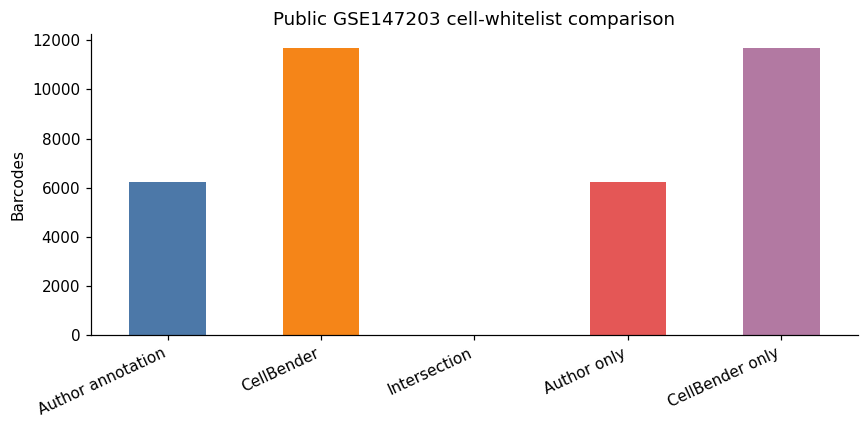

In [3]:
ax = comparison.plot.bar(color=["#4c78a8", "#f58518", "#54a24b", "#e45756", "#b279a2"], figsize=(8, 4))
ax.set_ylabel("Barcodes")
ax.set_title("Public GSE147203 cell-whitelist comparison")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Use the CellBender whitelist with AmbiDose

In [4]:
inspection = amdose.inspect_input(RAW_H5, cell_barcodes=CELLBENDER_FILTERED)
pd.Series(inspection)

/home/lieber/miniforge3/envs/python/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/lieber/miniforge3/envs/python/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


kind                                                                          h5
input                          /home/lieber/AmbiDose/data/raw/GSE147203/GSM42...
raw_matrix                     /home/lieber/AmbiDose/data/raw/GSE147203/GSM42...
n_droplets                                                                737280
n_genes                                                                    60736
estimated_matrix_memory_gib                                             0.164812
empty_umi_max                                                                100
n_empty_candidates                                                        452343
whitelist_source               /home/lieber/AmbiDose/data/processed/gse147203...
whitelist_mode                                                          external
feature_types                                         {'Gene Expression': 60736}
gene_symbol_style                                                   undetermined
obs_columns                 

In [5]:
raw = amdose.read_10x_h5(RAW_H5)
amdose.classify_droplets(raw, cell_barcodes=CELLBENDER_FILTERED, empty_umi_max=100)
amdose.estimate_chi(raw, sample_key=None)

cb_cells = raw[raw.obs[DROPLET_KEY].astype(str) == "cell"].copy()
cb_cells.var[CHI_KEY] = raw.var[CHI_KEY].to_numpy()
del raw
assign_majority_genome(cb_cells)
umi = umi_by_genome(cb_cells)
purity = umi.max(axis=1) / umi.sum(axis=1).clip(lower=1)
cb_cells = cb_cells[purity >= 0.75].copy()
cb_cells.obs[DROPLET_KEY] = "cell"

before = leakage_by_species(cb_cells).assign(stage="Raw")
amdose.denoise(cb_cells, type_key="ambidose_species", sample_key=None)
after = leakage_by_species(cb_cells, layer=LAYER_OUT).assign(stage="AmbiDose")
cellbender_leakage = pd.concat([before, after], ignore_index=True)
cellbender_leakage[["stage", "species", "n_cells", "leakage_mean", "off_umi_mean"]]

/home/lieber/miniforge3/envs/python/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/lieber/miniforge3/envs/python/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


ambidose: estimating per-cell ambient dose...


ambidose: estimating per-cell ambient dose completed in 23.3s


ambidose: subtracting ambient counts...


ambidose: subtracting ambient counts completed in 8.9s


ambidose: denoise completed
  cells corrected:             7,566
  reference empty droplets:    0
  median estimated ambient:    9.9%
  median ambient UMI per cell: 456.0
  median dose actually removed: 20.4%
  corrected counts:            layers['ambidose_denoised']
ambidose: QC for estimated ambient fractions
  suitable for interpretation: 2,213 cells (29.2%)
  interpret with caution:      5,353 cells (70.8%)
    67: too few informative genes
    5,228: less than half of estimated dose removed
    58: removal exceeded dose or half of cell UMIs
ambidose: QC flags concern interpretation of obs['ambidose_rho']; they are not a recommendation to remove those cells. See the QC report or obs['ambidose_rho_trust'] for cell-level details.


,stage,species,n_cells,leakage_mean,off_umi_mean
0,Raw,hg19,5777,0.039959,78.511684
1,Raw,mm10,1789,0.050649,252.143656
2,AmbiDose,hg19,5777,0.001142,1.126017
3,AmbiDose,mm10,1789,0.001601,5.271660


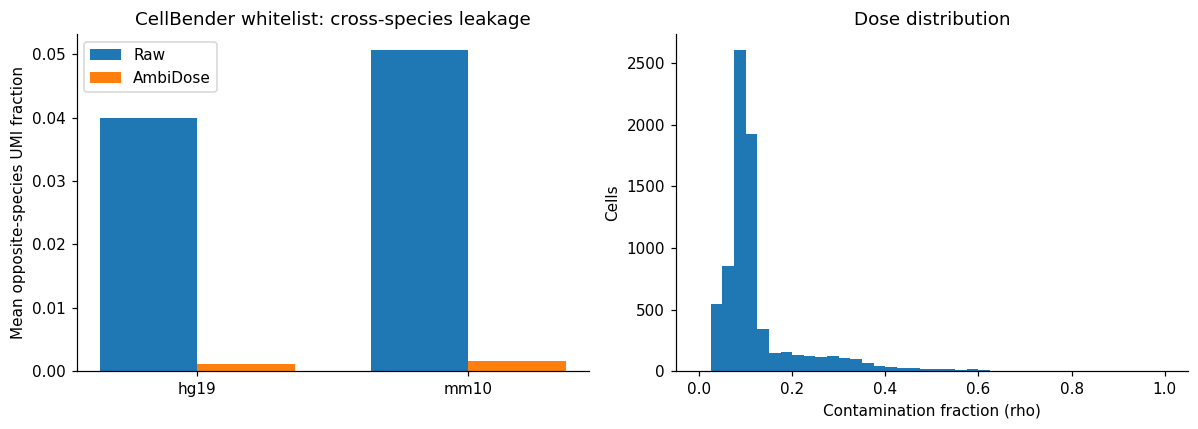

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for stage, group in cellbender_leakage.groupby("stage", sort=False):
    axes[0].bar(np.arange(len(group)) + (-0.18 if stage == "Raw" else 0.18), group["leakage_mean"], width=0.36, label=stage)
axes[0].set_xticks(range(len(before)), before["species"])
axes[0].set_ylabel("Mean opposite-species UMI fraction")
axes[0].set_title("CellBender whitelist: cross-species leakage")
axes[0].legend()
amdose.pl.dose_distribution(cb_cells, ax=axes[1])
fig.tight_layout()
plt.show()

## Extract an EmptyDrops whitelist from the same public raw matrix

Run this R code in an environment with Bioconductor DropletUtils. EmptyDrops
uses Monte Carlo sampling, so the seed and FDR threshold must be reported.

```r
library(DropletUtils)

raw_h5 <- "data/raw/GSE147203/GSM4228200_MF179_raw_gene_bc_matrices_h5.h5"
sce <- read10xCounts(raw_h5, col.names = TRUE)
set.seed(100)
ed <- emptyDrops(counts(sce))
keep <- !is.na(ed$FDR) & ed$FDR <= 0.001
writeLines(colnames(sce)[keep], "/tmp/gse147203_emptydrops_barcodes.tsv")
```

Then inject the resulting barcode-only TSV exactly like CellBender:

In [7]:
emptydrops_path = Path("/tmp/gse147203_emptydrops_barcodes.tsv")
if emptydrops_path.exists():
    emptydrops_inspection = amdose.inspect_input(RAW_H5, cell_barcodes=emptydrops_path)
    print(pd.Series(emptydrops_inspection))
    # Direct high-level use:
    # amdose.denoise(raw, cell_barcodes=emptydrops_path, sample_key=None)
else:
    print("EmptyDrops TSV not present: run the R block above in a DropletUtils environment.")

EmptyDrops TSV not present: run the R block above in a DropletUtils environment.


## Interpretation

`emptyDrops()` identifies statistically nonempty droplets, which are not
necessarily high-quality singlets. Mitochondrial, library-complexity, and
doublet filters should therefore be applied after ambient-profile estimation.
The CellBender-corrected, cell-only matrix should not replace the raw droplet
input because it lacks the empty droplets required to estimate that profile.